In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
pd.set_option("display.max_columns", None)

In [60]:
df = pd.read_csv('creditcard.csv')

In [61]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [62]:
df.shape

(284807, 31)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [64]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [65]:
df.duplicated().sum()

np.int64(1081)

In [66]:
df["Class"].value_counts()
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


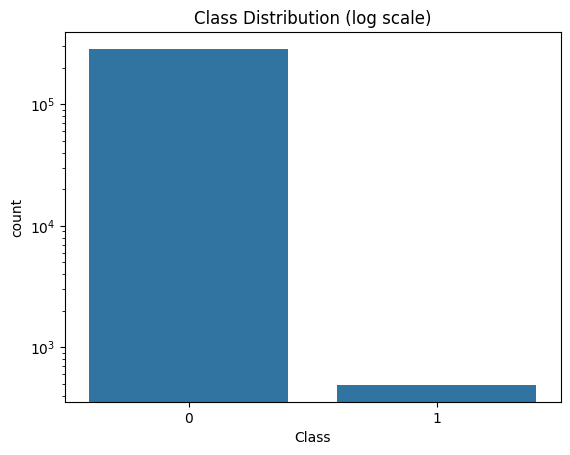

In [67]:
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (log scale)")
plt.yscale("log")
plt.show()

In [68]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


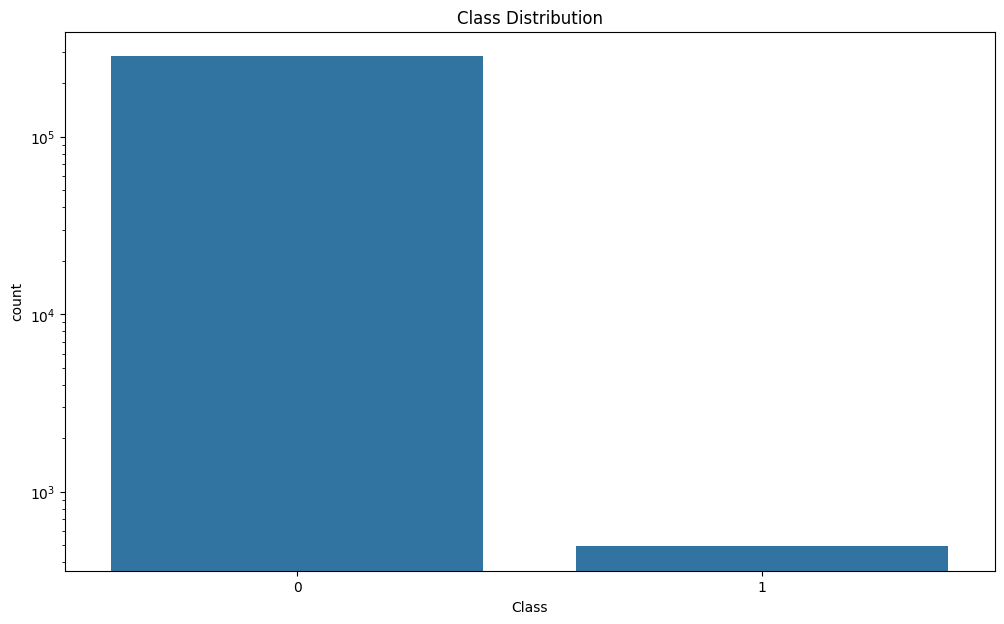

In [84]:
plt.figure(figsize = (12, 7))
sns.countplot(x = "Class", data = df)
plt.title("Class Distribution")
plt.yscale("log")
plt.show()

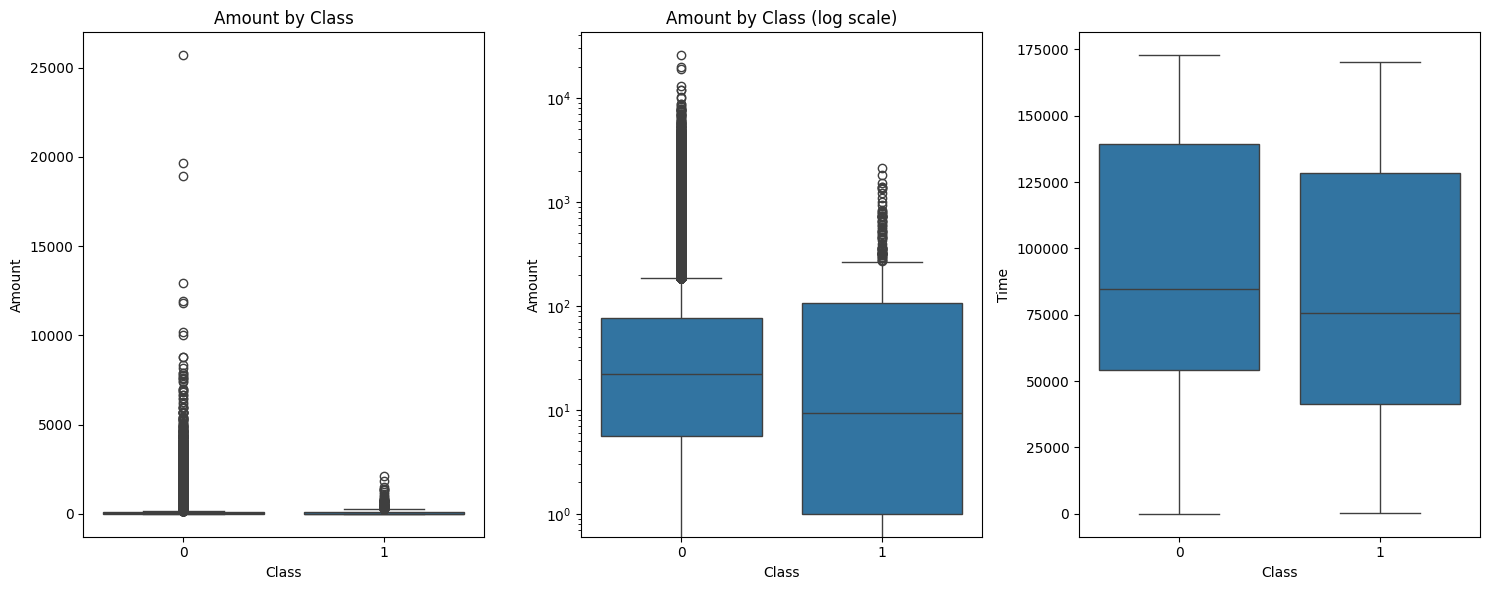

In [95]:
from re import X
fig, axes = plt.subplots(1, 3, figsize= (15, 6))
sns.boxplot(x="Class", y="Amount", data= df, ax=axes[0])
axes[0].set_title("Amount by Class")

sns.boxplot(x="Class", y="Amount", data=df, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Amount by Class (log scale)")

sns.boxplot(x="Class", y="Time", data=df, ax=axes[2])

plt.tight_layout()
plt.show()

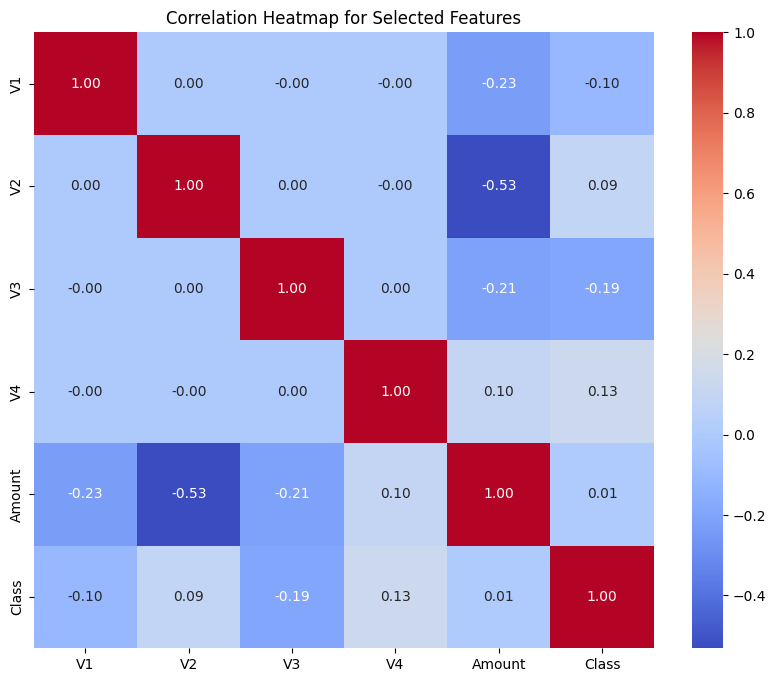

In [103]:
plt.figure(figsize=(10, 8))
corr = df[['V1', 'V2', 'V3', 'V4', 'Amount', 'Class']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Correlation Heatmap for Selected Features")
plt.show()

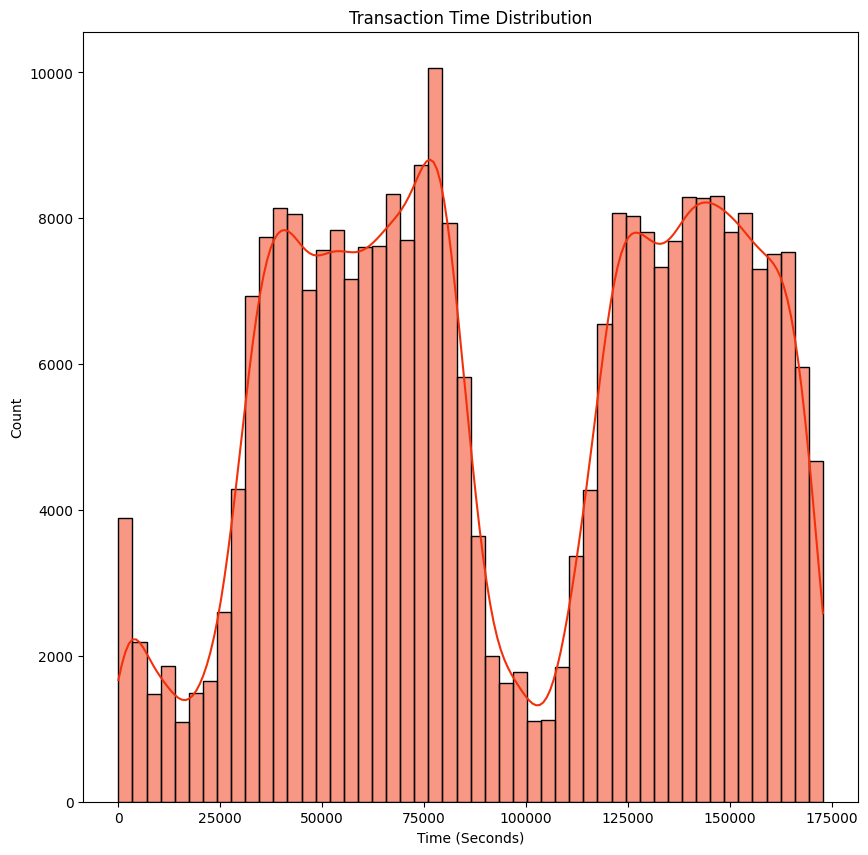

In [110]:
plt.figure(figsize=(10, 10))
sns.histplot(df["Time"], bins=50, kde=True, color="#F2300A")
plt.title("Transaction Time Distribution")
plt.xlabel("Time (Seconds)")
plt.ylabel("Count")
plt.show()

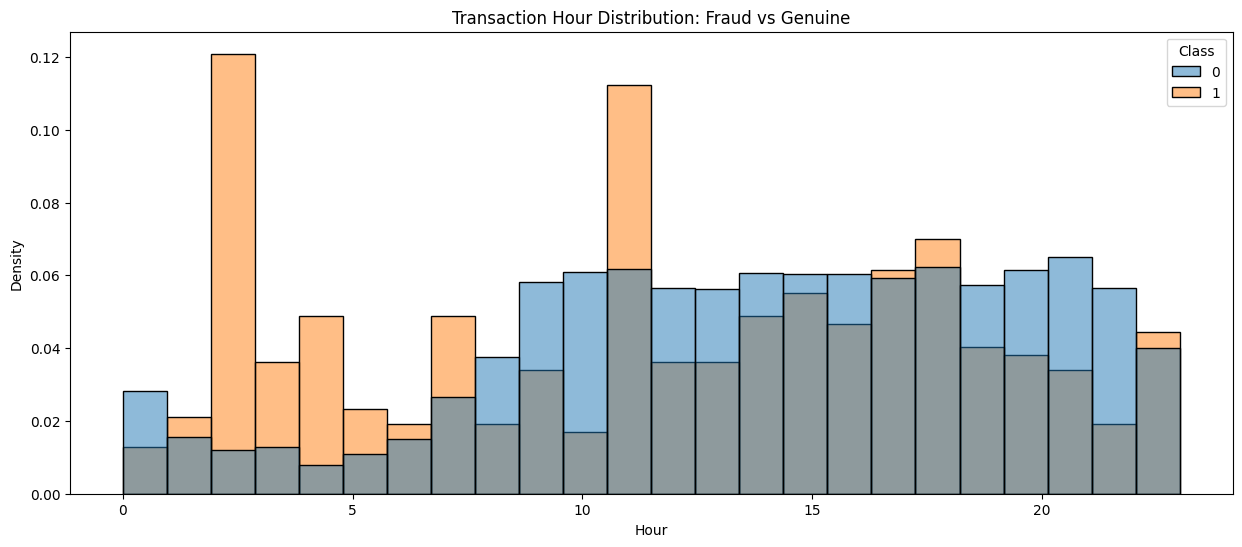

In [116]:
df["Hour"] = (df["Time"] // 3600) % 24

plt.figure(figsize=(15, 6))
sns.histplot(data= df, x="Hour", hue="Class", stat="density", common_norm=False, bins=24)
plt.title("Transaction Hour Distribution: Fraud vs Genuine")
plt.show()

In [113]:
fraud = df[df["Class"] == 1]
genuine = df[df["Class"] == 0]

for col in ["V1", "V2", "V3", "V4"]:
    print(col, "-> fraud mean:", round(fraud[col].mean(), 2),
          "| genuine mean:", round(genuine[col].mean(), 2))

V1 -> fraud mean: -4.77 | genuine mean: 0.01
V2 -> fraud mean: 3.62 | genuine mean: -0.01
V3 -> fraud mean: -7.03 | genuine mean: 0.01
V4 -> fraud mean: 4.54 | genuine mean: -0.01
